# RAG Pipeline Design
### Vector Search · Hybrid Retrieval · Citation Tracking

This notebook builds a production-grade Retrieval-Augmented Generation (RAG) pipeline from scratch, covering:

| Section | Topic |
|---------|-------|
| 0 | Setup & shared data models |
| 1 | Document ingestion & chunking strategies |
| 2 | Embedding generation & vector store |
| 3 | BM25 keyword (sparse) retrieval |
| 4 | Hybrid retrieval with Reciprocal Rank Fusion |
| 5 | Reranking |
| 6 | Citation tracking & grounded generation |
| 7 | End-to-end RAG pipeline |
| 8 | Evaluation (faithfulness, relevance, citation accuracy) |
| 9 | Visualisation & diagnostics |

---
## 0. Setup & Shared Data Models

In [1]:
!pip install anthropic openai numpy faiss-cpu rank-bm25 tiktoken rouge-score \
             sentence-transformers pandas matplotlib seaborn scikit-learn --quiet

In [2]:
import os, re, json, time, hashlib, textwrap
from dataclasses import dataclass, field
from typing import Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import anthropic

# ── Anthropic client ──────────────────────────────────────────────────────────
with open("config.json", "r") as f:
    config = json.load(f)

API_KEY = config["API_KEY"]
MODEL = config["MODEL"]
client  = anthropic.Anthropic(api_key=API_KEY)
MODEL  = "claude-sonnet-4-6"

# ── Core data models ─────────────────────────────────────────────────────────

@dataclass
class Document:
    """A source document before chunking."""
    doc_id:   str
    title:    str
    text:     str
    source:   str = ""          # URL, file path, ISBN, etc.
    metadata: dict = field(default_factory=dict)


@dataclass
class Chunk:
    """A retrievable text unit derived from a Document."""
    chunk_id:   str
    doc_id:     str
    doc_title:  str
    doc_source: str
    text:       str
    chunk_idx:  int             # position within the source doc
    start_char: int = 0
    end_char:   int = 0
    metadata:   dict = field(default_factory=dict)
    embedding:  Optional[np.ndarray] = field(default=None, repr=False)


@dataclass
class RetrievedChunk:
    """A chunk annotated with retrieval scores."""
    chunk:        Chunk
    vector_score: float = 0.0   # cosine similarity
    bm25_score:   float = 0.0   # BM25 score
    rrf_score:    float = 0.0   # Reciprocal Rank Fusion score
    rerank_score: float = 0.0   # cross-encoder rerank score
    final_score:  float = 0.0


@dataclass
class Citation:
    """A traceable reference from a generated answer back to a source chunk."""
    citation_id:  int
    chunk_id:     str
    doc_id:       str
    doc_title:    str
    doc_source:   str
    quote:        str           # verbatim excerpt used
    relevance:    float = 1.0


@dataclass
class RAGResponse:
    """Final grounded answer with full provenance."""
    query:        str
    answer:       str
    citations:    list[Citation]
    chunks_used:  list[RetrievedChunk]
    latency_s:    float = 0.0
    input_tokens: int   = 0
    output_tokens:int   = 0

print("Data models loaded ✓")

Data models loaded ✓


---
## 1. Document Ingestion & Chunking

Chunking strategy affects retrieval precision more than almost any other design choice.

| Strategy | Best for | Pros | Cons |
|----------|----------|------|------|
| **Fixed-size** | Homogeneous prose | Simple | Breaks mid-sentence |
| **Sentence-aware** | Articles, books | Coherent units | Variable length |
| **Recursive** | Mixed content | Respects structure | Slower |
| **Semantic** | Dense technical docs | Context-aware | Requires embeddings |
| **Parent-child** | Hierarchical docs | Best of both | More complex |

In [3]:
import tiktoken

_enc = tiktoken.get_encoding("cl100k_base")

def token_len(text: str) -> int:
    return len(_enc.encode(text))


# ── 1a. Fixed-size chunking with overlap ─────────────────────────────────────

def chunk_fixed(doc: Document,
                chunk_size: int = 256,
                overlap: int = 32) -> list[Chunk]:
    """Split by token count with a sliding-window overlap."""
    tokens  = _enc.encode(doc.text)
    chunks  = []
    start   = 0
    idx     = 0
    while start < len(tokens):
        end   = min(start + chunk_size, len(tokens))
        text  = _enc.decode(tokens[start:end])
        cid   = hashlib.md5(f"{doc.doc_id}:{idx}".encode()).hexdigest()[:12]
        chunks.append(Chunk(
            chunk_id=cid, doc_id=doc.doc_id, doc_title=doc.title,
            doc_source=doc.source, text=text, chunk_idx=idx,
        ))
        start += chunk_size - overlap
        idx   += 1
    return chunks


# ── 1b. Sentence-aware chunking ───────────────────────────────────────────────

def chunk_sentences(doc: Document,
                    max_tokens: int = 256,
                    overlap_sentences: int = 1) -> list[Chunk]:
    """Group sentences into chunks respecting token budget."""
    sentences = re.split(r'(?<=[.!?])\s+', doc.text.strip())
    chunks, buf, buf_tok, idx = [], [], 0, 0

    def flush():
        nonlocal buf, buf_tok, idx
        if not buf: return
        text = " ".join(buf)
        cid  = hashlib.md5(f"{doc.doc_id}:{idx}".encode()).hexdigest()[:12]
        chunks.append(Chunk(
            chunk_id=cid, doc_id=doc.doc_id, doc_title=doc.title,
            doc_source=doc.source, text=text, chunk_idx=idx,
        ))
        buf     = buf[-overlap_sentences:]  # carry over for overlap
        buf_tok = sum(token_len(s) for s in buf)
        idx    += 1

    for sent in sentences:
        t = token_len(sent)
        if buf_tok + t > max_tokens:
            flush()
        buf.append(sent)
        buf_tok += t
    flush()
    return chunks


# ── 1c. Parent-child chunking ─────────────────────────────────────────────────
# Small child chunks are retrieved; large parent chunks are sent to the LLM.

def chunk_parent_child(doc: Document,
                       parent_size: int = 512,
                       child_size:  int = 128) -> tuple[list[Chunk], dict]:
    """Returns (child_chunks, parent_map) where parent_map[child_id] = parent_chunk."""
    parents = chunk_fixed(doc, chunk_size=parent_size, overlap=0)
    children, parent_map = [], {}
    for parent in parents:
        sub_doc = Document(
            doc_id=f"{doc.doc_id}_p{parent.chunk_idx}",
            title=doc.title, text=parent.text, source=doc.source,
        )
        for child in chunk_fixed(sub_doc, chunk_size=child_size, overlap=16):
            children.append(child)
            parent_map[child.chunk_id] = parent
    return children, parent_map


# ── Demo corpus ───────────────────────────────────────────────────────────────
CORPUS = [
    Document(
        doc_id="doc1", title="Introduction to Transformers",
        source="https://arxiv.org/abs/1706.03762",
        text=(
            "The Transformer architecture was introduced in the seminal 2017 paper "
            "'Attention Is All You Need' by Vaswani et al. Unlike previous sequence "
            "models based on RNNs, Transformers rely entirely on self-attention mechanisms "
            "to draw global dependencies between input and output. The model consists of "
            "an encoder and a decoder, each made up of stacked identical layers. Each layer "
            "in the encoder has two sub-layers: a multi-head self-attention mechanism, and "
            "a position-wise fully connected feed-forward network. Residual connections and "
            "layer normalisation are applied around each sub-layer. Positional encodings are "
            "added to the input embeddings to inject information about the order of tokens, "
            "since the model has no recurrence or convolution."
        ),
    ),
    Document(
        doc_id="doc2", title="BERT: Pre-training Deep Bidirectional Transformers",
        source="https://arxiv.org/abs/1810.04805",
        text=(
            "BERT (Bidirectional Encoder Representations from Transformers) was introduced "
            "by Devlin et al. in 2018. BERT is designed to pre-train deep bidirectional "
            "representations from unlabelled text by jointly conditioning on both left and "
            "right context in all layers. The pre-trained BERT model can be fine-tuned with "
            "just one additional output layer to create state-of-the-art models for a wide "
            "range of NLP tasks. BERT uses Masked Language Modelling (MLM) and Next Sentence "
            "Prediction (NSP) as pre-training objectives. The masked LM randomly masks some "
            "tokens from the input and predicts them. BERT achieved new state-of-the-art on "
            "eleven NLP benchmarks at the time of release."
        ),
    ),
    Document(
        doc_id="doc3", title="Retrieval-Augmented Generation (RAG)",
        source="https://arxiv.org/abs/2005.11401",
        text=(
            "Retrieval-Augmented Generation (RAG), introduced by Lewis et al. in 2020, "
            "combines parametric memory (the language model weights) with non-parametric "
            "memory (a dense vector retrieval index). During inference, relevant documents "
            "are retrieved from the index using a dense passage retriever (DPR) and "
            "concatenated with the input query before being passed to a seq2seq generator. "
            "This allows the model to generate responses grounded in up-to-date external "
            "knowledge without full re-training. RAG was shown to outperform parametric-only "
            "models on open-domain question answering benchmarks including Natural Questions, "
            "TriviaQA, and WebQuestions. The retrieval component is a bi-encoder that embeds "
            "both queries and passages into a shared dense vector space."
        ),
    ),
    Document(
        doc_id="doc4", title="Vector Databases and ANN Search",
        source="https://example.com/vector-databases",
        text=(
            "Vector databases are purpose-built systems for storing, indexing, and "
            "querying high-dimensional embedding vectors. Approximate Nearest Neighbour "
            "(ANN) algorithms such as HNSW (Hierarchical Navigable Small World), IVF "
            "(Inverted File Index), and PQ (Product Quantization) enable sub-linear "
            "query time at the cost of a small recall trade-off. Popular vector databases "
            "include FAISS (Meta), Pinecone, Weaviate, Qdrant, and Chroma. FAISS supports "
            "both exact L2 / inner-product search and approximate HNSW / IVF indexes. "
            "For hybrid retrieval, many systems support pre-filtering by metadata and "
            "combining sparse (BM25) and dense (embedding) scores through Reciprocal Rank "
            "Fusion or learned sparse-dense fusion models."
        ),
    ),
]

chunks = []
for doc in CORPUS:
    chunks.extend(chunk_sentences(doc, max_tokens=100))

print(f"Corpus: {len(CORPUS)} docs → {len(chunks)} chunks")
for c in chunks[:3]:
    print(f"  [{c.chunk_id}] {c.doc_title[:40]} | {token_len(c.text)} tokens")

Corpus: 4 docs → 8 chunks
  [c56dea0f7ece] Introduction to Transformers | 100 tokens
  [b5042beaf2bf] Introduction to Transformers | 71 tokens
  [e0caff8cc555] BERT: Pre-training Deep Bidirectional Tr | 86 tokens


---
## 2. Embedding Generation & Vector Store

We use **FAISS** for the in-process vector index and Anthropic's embedding endpoint (or `sentence-transformers` as a free fallback).

In [4]:
import faiss
from sentence_transformers import SentenceTransformer

# ── Embedding model (local, no API key needed) ────────────────────────────────
_embed_model = SentenceTransformer("all-MiniLM-L6-v2")  # 384-dim, fast

def embed_texts(texts: list[str], batch_size: int = 64) -> np.ndarray:
    """Return L2-normalised embeddings (shape N x D)."""
    vecs = _embed_model.encode(
        texts, batch_size=batch_size,
        show_progress_bar=len(texts) > 100, normalize_embeddings=True,
    )
    return vecs.astype(np.float32)


# ── FAISS vector store ────────────────────────────────────────────────────────

class VectorStore:
    """Flat inner-product index (cosine after L2 normalisation)."""

    def __init__(self, dim: int):
        self.index  = faiss.IndexFlatIP(dim)   # inner product == cosine for unit vecs
        self.chunks: list[Chunk] = []
        self.dim    = dim

    def add(self, chunks: list[Chunk]):
        texts = [c.text for c in chunks]
        vecs  = embed_texts(texts)
        self.index.add(vecs)
        for c, v in zip(chunks, vecs):
            c.embedding = v
        self.chunks.extend(chunks)
        print(f"VectorStore: {self.index.ntotal} vectors indexed (dim={self.dim})")

    def search(self, query: str, k: int = 5) -> list[RetrievedChunk]:
        q_vec = embed_texts([query])             # shape (1, D)
        scores, idxs = self.index.search(q_vec, k)
        results = []
        for score, idx in zip(scores[0], idxs[0]):
            if idx < 0: continue
            rc = RetrievedChunk(chunk=self.chunks[idx], vector_score=float(score))
            rc.final_score = rc.vector_score
            results.append(rc)
        return results


# ── Build index ───────────────────────────────────────────────────────────────
DIM        = 384
vector_store = VectorStore(dim=DIM)
vector_store.add(chunks)

/Users/shraddhasharma/Desktop/pp/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10529.46it/s]


VectorStore: 8 vectors indexed (dim=384)


In [5]:
# ── Quick vector search demo ──────────────────────────────────────────────────
query = "How does self-attention work in Transformers?"
results = vector_store.search(query, k=3)

print(f"Query: {query}\n")
for i, rc in enumerate(results, 1):
    print(f"  [{i}] score={rc.vector_score:.4f} | {rc.chunk.doc_title}")
    print(f"       {rc.chunk.text[:120]}...\n")

Query: How does self-attention work in Transformers?

  [1] score=0.6519 | Introduction to Transformers
       The Transformer architecture was introduced in the seminal 2017 paper 'Attention Is All You Need' by Vaswani et al. Unli...

  [2] score=0.4544 | Introduction to Transformers
       Each layer in the encoder has two sub-layers: a multi-head self-attention mechanism, and a position-wise fully connected...

  [3] score=0.3386 | BERT: Pre-training Deep Bidirectional Transformers
       BERT (Bidirectional Encoder Representations from Transformers) was introduced by Devlin et al. in 2018. BERT is designed...



---
## 3. BM25 Keyword (Sparse) Retrieval

BM25 excels at **exact-match** and **rare-term** queries where dense embeddings under-perform.

In [6]:
from rank_bm25 import BM25Okapi

class BM25Index:
    def __init__(self, chunks: list[Chunk]):
        self.chunks = chunks
        tokenised   = [self._tokenise(c.text) for c in chunks]
        self.bm25   = BM25Okapi(tokenised)
        print(f"BM25 index built over {len(chunks)} chunks")

    @staticmethod
    def _tokenise(text: str) -> list[str]:
        return re.findall(r'\w+', text.lower())

    def search(self, query: str, k: int = 5) -> list[RetrievedChunk]:
        tokens = self._tokenise(query)
        scores = self.bm25.get_scores(tokens)
        top_k  = np.argsort(scores)[::-1][:k]
        results = []
        for idx in top_k:
            if scores[idx] <= 0:
                continue
            rc = RetrievedChunk(chunk=self.chunks[idx], bm25_score=float(scores[idx]))
            rc.final_score = rc.bm25_score
            results.append(rc)
        return results


bm25_index = BM25Index(chunks)

# Demo
query = "masked language modelling pre-training objective"
bm25_results = bm25_index.search(query, k=3)
print(f"\nBM25 results for: '{query}'")
for i, rc in enumerate(bm25_results, 1):
    print(f"  [{i}] BM25={rc.bm25_score:.3f} | {rc.chunk.doc_title}")
    print(f"       {rc.chunk.text[:120]}...\n")

BM25 index built over 8 chunks

BM25 results for: 'masked language modelling pre-training objective'
  [1] BM25=5.700 | BERT: Pre-training Deep Bidirectional Transformers
       The pre-trained BERT model can be fine-tuned with just one additional output layer to create state-of-the-art models for...

  [2] BM25=1.336 | Retrieval-Augmented Generation (RAG)
       Retrieval-Augmented Generation (RAG), introduced by Lewis et al. in 2020, combines parametric memory (the language model...

  [3] BM25=0.640 | BERT: Pre-training Deep Bidirectional Transformers
       BERT (Bidirectional Encoder Representations from Transformers) was introduced by Devlin et al. in 2018. BERT is designed...



---
## 4. Hybrid Retrieval with Reciprocal Rank Fusion (RRF)

**RRF** merges ranked lists from different retrievers without requiring score normalisation.

$$\text{RRF}(d) = \sum_{r \in \text{rankers}} \frac{1}{k + \text{rank}_r(d)}$$

where $k=60$ is a smoothing constant that reduces the impact of very high ranks.

In [7]:
def reciprocal_rank_fusion(
    ranked_lists: list[list[RetrievedChunk]],
    k: int = 60,
    top_n: int = 10,
) -> list[RetrievedChunk]:
    """
    Merge multiple ranked retrieval lists using RRF.
    Returns a new list of RetrievedChunk sorted by descending RRF score.
    """
    rrf_scores: dict[str, float]         = {}
    chunk_map:  dict[str, RetrievedChunk] = {}

    for ranked in ranked_lists:
        for rank, rc in enumerate(ranked, start=1):
            cid = rc.chunk.chunk_id
            rrf_scores[cid] = rrf_scores.get(cid, 0.0) + 1.0 / (k + rank)
            if cid not in chunk_map:
                chunk_map[cid] = rc
            else:
                # merge per-retriever scores onto the same object
                existing = chunk_map[cid]
                existing.vector_score = max(existing.vector_score, rc.vector_score)
                existing.bm25_score   = max(existing.bm25_score,   rc.bm25_score)

    sorted_ids = sorted(rrf_scores, key=rrf_scores.get, reverse=True)[:top_n]
    results = []
    for cid in sorted_ids:
        rc = chunk_map[cid]
        rc.rrf_score   = round(rrf_scores[cid], 6)
        rc.final_score = rc.rrf_score
        results.append(rc)
    return results


class HybridRetriever:
    """Combines dense vector search and BM25 via RRF."""

    def __init__(self,
                 vector_store: VectorStore,
                 bm25_index:   BM25Index,
                 vector_k: int = 10,
                 bm25_k:   int = 10,
                 rrf_k:    int = 60,
                 top_n:    int = 5):
        self.vs      = vector_store
        self.bm25    = bm25_index
        self.vector_k = vector_k
        self.bm25_k   = bm25_k
        self.rrf_k    = rrf_k
        self.top_n    = top_n

    def retrieve(self, query: str) -> list[RetrievedChunk]:
        dense  = self.vs.search(query,   k=self.vector_k)
        sparse = self.bm25.search(query, k=self.bm25_k)
        fused  = reciprocal_rank_fusion([dense, sparse],
                                        k=self.rrf_k, top_n=self.top_n)
        return fused


hybrid = HybridRetriever(vector_store, bm25_index, top_n=5)

# Demo
query   = "How does RAG combine parametric and non-parametric memory?"
results = hybrid.retrieve(query)
print(f"Hybrid results for: '{query}'\n")
print(f"{'Rank':<5} {'RRF':>7} {'Vec':>7} {'BM25':>7}  Title")
print("-"*65)
for i, rc in enumerate(results, 1):
    print(f"{i:<5} {rc.rrf_score:>7.5f} {rc.vector_score:>7.4f} {rc.bm25_score:>7.3f}  {rc.chunk.doc_title[:35]}")

Hybrid results for: 'How does RAG combine parametric and non-parametric memory?'

Rank      RRF     Vec    BM25  Title
-----------------------------------------------------------------
1     0.03279  0.4708   7.574  Retrieval-Augmented Generation (RAG
2     0.03226  0.3464   3.502  Retrieval-Augmented Generation (RAG
3     0.03101  0.2139   0.488  Introduction to Transformers
4     0.03080  0.1067   0.589  Vector Databases and ANN Search
5     0.03058  0.2172   0.307  BERT: Pre-training Deep Bidirection


---
## 5. Reranking

After retrieval, a **cross-encoder reranker** scores each *(query, chunk)* pair jointly — much more accurate than bi-encoder similarity, but too slow to run over the full corpus.

In [8]:
from sentence_transformers import CrossEncoder

class CrossEncoderReranker:
    """Reranks retrieved chunks using a cross-encoder model."""

    def __init__(self, model_name: str = "cross-encoder/ms-marco-MiniLM-L-6-v2"):
        self.model = CrossEncoder(model_name)
        print(f"CrossEncoder loaded: {model_name}")

    def rerank(self, query: str,
               candidates: list[RetrievedChunk],
               top_n: int = 5) -> list[RetrievedChunk]:
        pairs   = [(query, rc.chunk.text) for rc in candidates]
        scores  = self.model.predict(pairs)       # shape (N,)
        for rc, s in zip(candidates, scores):
            rc.rerank_score = float(s)
            rc.final_score  = rc.rerank_score
        reranked = sorted(candidates, key=lambda x: x.rerank_score, reverse=True)
        return reranked[:top_n]


# ── LLM-based reranker (no cross-encoder dependency) ─────────────────────────

LLM_RERANK_PROMPT = """\
Given the following QUERY and a list of PASSAGES, rank the passages \
from most to least relevant.

QUERY: {query}

PASSAGES:
{passages}

Return ONLY a JSON array of passage indices (0-based) in descending relevance order.
Example: [2, 0, 4, 1, 3]
"""

def llm_rerank(query: str, candidates: list[RetrievedChunk],
               top_n: int = 5) -> list[RetrievedChunk]:
    """Rerank using the LLM as a zero-shot relevance judge."""
    passages = "\n".join(
        f"[{i}] {rc.chunk.text[:300]}" for i, rc in enumerate(candidates)
    )
    prompt = LLM_RERANK_PROMPT.format(query=query, passages=passages)
    resp   = client.messages.create(
        model=MODEL, max_tokens=128,
        messages=[{"role": "user", "content": prompt}],
    )
    raw = resp.content[0].text.strip()
    try:
        order = json.loads(re.search(r'\[.*\]', raw, re.DOTALL).group())
        reranked = [candidates[i] for i in order if i < len(candidates)]
        for rank, rc in enumerate(reranked):
            rc.rerank_score = 1.0 - rank / len(reranked)
            rc.final_score  = rc.rerank_score
        return reranked[:top_n]
    except Exception as e:
        print(f"LLM rerank parse error: {e}")
        return candidates[:top_n]


# ── Instantiate cross-encoder (downloads ~25 MB on first run) ─────────────────
reranker = CrossEncoderReranker()

# Demo pipeline: hybrid → rerank
query        = "What is BERT and how is it pre-trained?"
candidates   = hybrid.retrieve(query)
reranked     = reranker.rerank(query, candidates, top_n=3)

print(f"\nTop-3 after reranking for: '{query}'\n")
for i, rc in enumerate(reranked, 1):
    print(f"  [{i}] rerank={rc.rerank_score:.3f} | {rc.chunk.doc_title}")
    print(f"       {rc.chunk.text[:120]}...\n")

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 7489.19it/s]


CrossEncoder loaded: cross-encoder/ms-marco-MiniLM-L-6-v2

Top-3 after reranking for: 'What is BERT and how is it pre-trained?'

  [1] rerank=7.139 | BERT: Pre-training Deep Bidirectional Transformers
       BERT (Bidirectional Encoder Representations from Transformers) was introduced by Devlin et al. in 2018. BERT is designed...

  [2] rerank=6.881 | BERT: Pre-training Deep Bidirectional Transformers
       The pre-trained BERT model can be fine-tuned with just one additional output layer to create state-of-the-art models for...

  [3] rerank=-10.836 | Retrieval-Augmented Generation (RAG)
       This allows the model to generate responses grounded in up-to-date external knowledge without full re-training. RAG was ...



---
## 6. Citation Tracking & Grounded Generation

**Citation tracking** ensures every claim in the generated answer traces back to a specific chunk. We use two strategies:

1. **Inline citation tags** — the LLM embeds `[N]` markers in its answer.
2. **Post-hoc extraction** — we parse the answer and verify each citation against retrieved chunks.

In [9]:
# ── 6a. Citation-aware generation prompt ─────────────────────────────────────

GENERATION_SYSTEM = """You are a grounded research assistant. \
Answer questions using ONLY the provided context passages. \
For every factual claim, cite the passage number(s) in square brackets like [1] or [1,2]. \
Never introduce information not present in the passages."""

GENERATION_USER_TEMPLATE = """\
CONTEXT PASSAGES:
{passages}

QUESTION: {question}

Provide a comprehensive answer with inline citations [N] for each claim."""


def build_context(retrieved: list[RetrievedChunk]) -> str:
    """Format retrieved chunks as numbered context passages."""
    lines = []
    for i, rc in enumerate(retrieved, 1):
        lines.append(
            f"[{i}] Source: {rc.chunk.doc_title} ({rc.chunk.doc_source})\n"
            f"    {rc.chunk.text.strip()}"
        )
    return "\n\n".join(lines)


# ── 6b. Citation parser ────────────────────────────────────────────────────────

def parse_citations(
    answer: str,
    retrieved: list[RetrievedChunk],
) -> list[Citation]:
    """
    Extract all [N] references from the answer and map them to
    the corresponding retrieved chunks.
    """
    citation_nums = sorted(set(
        int(n) for n in re.findall(r'\[(\d+)\]', answer)
    ))
    citations = []
    for n in citation_nums:
        idx = n - 1   # 1-based → 0-based
        if idx < 0 or idx >= len(retrieved):
            continue
        rc   = retrieved[idx]
        cite = Citation(
            citation_id = n,
            chunk_id    = rc.chunk.chunk_id,
            doc_id      = rc.chunk.doc_id,
            doc_title   = rc.chunk.doc_title,
            doc_source  = rc.chunk.doc_source,
            quote       = rc.chunk.text[:200],
            relevance   = rc.final_score,
        )
        citations.append(cite)
    return citations


# ── 6c. Hallucination guard ────────────────────────────────────────────────────

FAITHFULNESS_PROMPT = """\
Determine whether each sentence in the ANSWER is supported by the CONTEXT.

CONTEXT:
{context}

ANSWER:
{answer}

Return JSON:
{{"faithfulness_score": <0.0-1.0>, \
"unsupported_claims": ["<claim>", ...], \
"explanation": "<brief>"}}
"""

def check_faithfulness(answer: str, context: str) -> dict:
    prompt = FAITHFULNESS_PROMPT.format(context=context, answer=answer)
    resp   = client.messages.create(
        model=MODEL, max_tokens=512,
        messages=[{"role": "user", "content": prompt}],
    )
    raw = resp.content[0].text.strip()
    try:
        return json.loads(re.search(r'\{.*\}', raw, re.DOTALL).group())
    except Exception:
        return {"faithfulness_score": 0.0, "unsupported_claims": [], "raw": raw}

print("Citation tracking utilities ready ✓")

Citation tracking utilities ready ✓


---
## 7. End-to-End RAG Pipeline

In [10]:
class RAGPipeline:
    """
    Full RAG pipeline:
      Query → Hybrid Retrieval → Rerank → Grounded Generation → Citation Tracking
    """

    def __init__(
        self,
        retriever:   HybridRetriever,
        reranker:    CrossEncoderReranker = None,
        top_k:       int  = 5,
        check_faith: bool = False,   # toggle faithfulness check (extra API call)
    ):
        self.retriever   = retriever
        self.reranker    = reranker
        self.top_k       = top_k
        self.check_faith = check_faith

    def run(self, query: str) -> RAGResponse:
        t0 = time.perf_counter()

        # ── 1. Retrieve ────────────────────────────────────────────────────────
        retrieved = self.retriever.retrieve(query)

        # ── 2. Rerank ──────────────────────────────────────────────────────────
        if self.reranker:
            retrieved = self.reranker.rerank(query, retrieved, top_n=self.top_k)
        else:
            retrieved = retrieved[:self.top_k]

        # ── 3. Build context ───────────────────────────────────────────────────
        context = build_context(retrieved)
        prompt  = GENERATION_USER_TEMPLATE.format(
            passages=context, question=query,
        )

        # ── 4. Generate ────────────────────────────────────────────────────────
        resp = client.messages.create(
            model=MODEL, max_tokens=1024,
            system=GENERATION_SYSTEM,
            messages=[{"role": "user", "content": prompt}],
        )
        answer = resp.content[0].text

        # ── 5. Parse citations ─────────────────────────────────────────────────
        citations = parse_citations(answer, retrieved)

        # ── 6. Optional faithfulness check ────────────────────────────────────
        faith = None
        if self.check_faith:
            faith = check_faithfulness(answer, context)

        rag_resp = RAGResponse(
            query         = query,
            answer        = answer,
            citations     = citations,
            chunks_used   = retrieved,
            latency_s     = round(time.perf_counter() - t0, 3),
            input_tokens  = resp.usage.input_tokens,
            output_tokens = resp.usage.output_tokens,
        )
        if faith:
            rag_resp.__dict__["faithfulness"] = faith  # attach for inspection
        return rag_resp


# ── Instantiate and run ───────────────────────────────────────────────────────
pipeline = RAGPipeline(
    retriever   = hybrid,
    reranker    = reranker,
    top_k       = 4,
    check_faith = True,
)

response = pipeline.run(
    "What techniques do RAG and BERT use to leverage external knowledge?"
)

print("\n" + "═"*70)
print("ANSWER")
print("═"*70)
print(response.answer)
print()
print("═"*70)
print("CITATIONS")
print("═"*70)
for c in response.citations:
    print(f"  [{c.citation_id}] {c.doc_title}")
    print(f"       source : {c.doc_source}")
    print(f"       excerpt: {c.quote[:100]}...\n")
print(f"Latency: {response.latency_s}s | "
      f"Tokens in/out: {response.input_tokens}/{response.output_tokens}")


══════════════════════════════════════════════════════════════════════
ANSWER
══════════════════════════════════════════════════════════════════════
## RAG and BERT: Approaches to Leveraging External Knowledge

These two architectures take fundamentally different approaches to incorporating knowledge:

### RAG's Approach: Dynamic External Retrieval

RAG explicitly leverages **non-parametric external knowledge** at inference time. It combines parametric memory (stored in language model weights) with non-parametric memory in the form of a dense vector retrieval index [2]. During inference, relevant documents are dynamically retrieved from this index using a Dense Passage Retriever (DPR) and concatenated with the input query before being passed to a seq2seq generator [2]. The retrieval component uses a **bi-encoder** that embeds both queries and passages into a shared dense vector space [1], enabling efficient similarity-based lookup. This design allows the model to generate responses gr

---
## 8. RAG Evaluation

| Metric | Measures | Method |
|--------|----------|--------|
| **Context Relevance** | Are retrieved chunks related to the query? | LLM judge |
| **Answer Faithfulness** | Does the answer stay within the context? | LLM judge |
| **Answer Relevance** | Does the answer address the question? | Embedding similarity |
| **Citation Precision** | Are cited chunks actually used? | Parse + verify |
| **Citation Recall** | Are all relevant chunks cited? | Overlap |
| **ROUGE-L** | Lexical overlap vs. reference | ROUGE |

In [11]:
from rouge_score import rouge_scorer as rs
_rouge = rs.RougeScorer(["rougeL"], use_stemmer=True)


# ── 8a. Context Relevance ─────────────────────────────────────────────────────

CTX_REL_PROMPT = """\
Score how relevant each passage is to the QUERY on a scale of 0 to 1.
QUERY: {query}
PASSAGES:
{passages}
Return JSON: {{"scores": [<0-1>, ...]}}
"""

def context_relevance(query: str, retrieved: list[RetrievedChunk]) -> float:
    passages = "\n".join(
        f"[{i+1}] {rc.chunk.text[:200]}" for i, rc in enumerate(retrieved)
    )
    prompt = CTX_REL_PROMPT.format(query=query, passages=passages)
    resp   = client.messages.create(
        model=MODEL, max_tokens=256,
        messages=[{"role": "user", "content": prompt}],
    )
    raw = resp.content[0].text
    try:
        data = json.loads(re.search(r'\{.*\}', raw, re.DOTALL).group())
        return round(float(np.mean(data["scores"])), 3)
    except Exception:
        return 0.0


# ── 8b. Answer Relevance (embedding cosine) ───────────────────────────────────

def answer_relevance(query: str, answer: str) -> float:
    vecs = embed_texts([query, answer])
    return float(np.dot(vecs[0], vecs[1]))   # cosine (L2-normalised)


# ── 8c. Citation precision & recall ──────────────────────────────────────────

def citation_metrics(
    answer:    str,
    retrieved: list[RetrievedChunk],
    citations: list[Citation],
) -> dict:
    cited_ids    = {c.chunk_id for c in citations}
    retrieval_ids = {rc.chunk.chunk_id for rc in retrieved}
    precision    = len(cited_ids & retrieval_ids) / max(len(cited_ids), 1)
    # recall: fraction of retrieved chunks that were actually cited
    recall       = len(cited_ids & retrieval_ids) / max(len(retrieval_ids), 1)
    return {
        "citation_precision": round(precision, 3),
        "citation_recall":    round(recall, 3),
        "n_cited":            len(cited_ids),
        "n_retrieved":        len(retrieval_ids),
    }


# ── 8d. Full eval suite ───────────────────────────────────────────────────────

def evaluate_rag_response(
    response: RAGResponse,
    reference: str = None,
) -> dict:
    metrics = {}
    metrics["context_relevance"] = context_relevance(
        response.query, response.chunks_used
    )
    metrics["answer_relevance"]  = round(
        answer_relevance(response.query, response.answer), 3
    )
    metrics.update(citation_metrics(
        response.answer, response.chunks_used, response.citations
    ))
    faith = getattr(response, "faithfulness", None)
    if isinstance(faith, dict):
        metrics["faithfulness"] = faith.get("faithfulness_score", None)
    if reference:
        metrics["rouge_l"] = round(
            _rouge.score(reference, response.answer)["rougeL"].fmeasure, 3
        )
    metrics["latency_s"]     = response.latency_s
    metrics["input_tokens"]  = response.input_tokens
    metrics["output_tokens"] = response.output_tokens
    return metrics


# Run evaluation
eval_result = evaluate_rag_response(response)
print("\nRAG Evaluation Metrics")
print("-"*40)
for k, v in eval_result.items():
    print(f"  {k:<25} {v}")


RAG Evaluation Metrics
----------------------------------------
  context_relevance         0.0
  answer_relevance          0.583
  citation_precision        1.0
  citation_recall           1.0
  n_cited                   4
  n_retrieved               4
  faithfulness              0.0
  latency_s                 18.197
  input_tokens              644
  output_tokens             406


In [12]:
# ── Multi-query benchmark ─────────────────────────────────────────────────────

BENCHMARK_QUERIES = [
    {"query": "How does the Transformer encoder work?",
     "reference": "The Transformer encoder uses multi-head self-attention and feed-forward layers with residual connections."},
    {"query": "What pre-training tasks does BERT use?",
     "reference": "BERT uses Masked Language Modelling and Next Sentence Prediction for pre-training."},
    {"query": "How does RAG differ from a pure language model?",
     "reference": "RAG combines a parametric LM with non-parametric retrieval from an external index."},
    {"query": "What ANN algorithms are used in vector databases?",
     "reference": "HNSW, IVF, and Product Quantization are common ANN algorithms in vector databases."},
]

benchmark_results = []
for item in BENCHMARK_QUERIES:
    print(f"Running: {item['query'][:50]}...")
    resp    = pipeline.run(item["query"])
    metrics = evaluate_rag_response(resp, reference=item["reference"])
    metrics["query"] = item["query"][:50]
    benchmark_results.append(metrics)

bench_df = pd.DataFrame(benchmark_results)
print("\nBenchmark complete.")
bench_df[["query", "context_relevance", "answer_relevance",
          "faithfulness", "citation_precision", "rouge_l"]]

Running: How does the Transformer encoder work?...
Running: What pre-training tasks does BERT use?...
Running: How does RAG differ from a pure language model?...
Running: What ANN algorithms are used in vector databases?...

Benchmark complete.


,query,context_relevance,answer_relevance,faithfulness,citation_precision,rouge_l
0,How does the Transformer encoder work?,0.537,0.596,1.0,1.0,0.105
1,What pre-training tasks does BERT use?,0.475,0.672,1.0,1.0,0.161
2,How does RAG differ from a pure language model?,0.500,0.683,1.0,1.0,0.069
3,What ANN algorithms are used in vector databases?,0.480,0.679,1.0,1.0,0.081


---
## 9. Visualisation & Diagnostics

/var/folders/4k/y1z0250n6kx6f5pt734bz7w40000gp/T/ipykernel_64042/3295243906.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/rag_diagnostics.png'

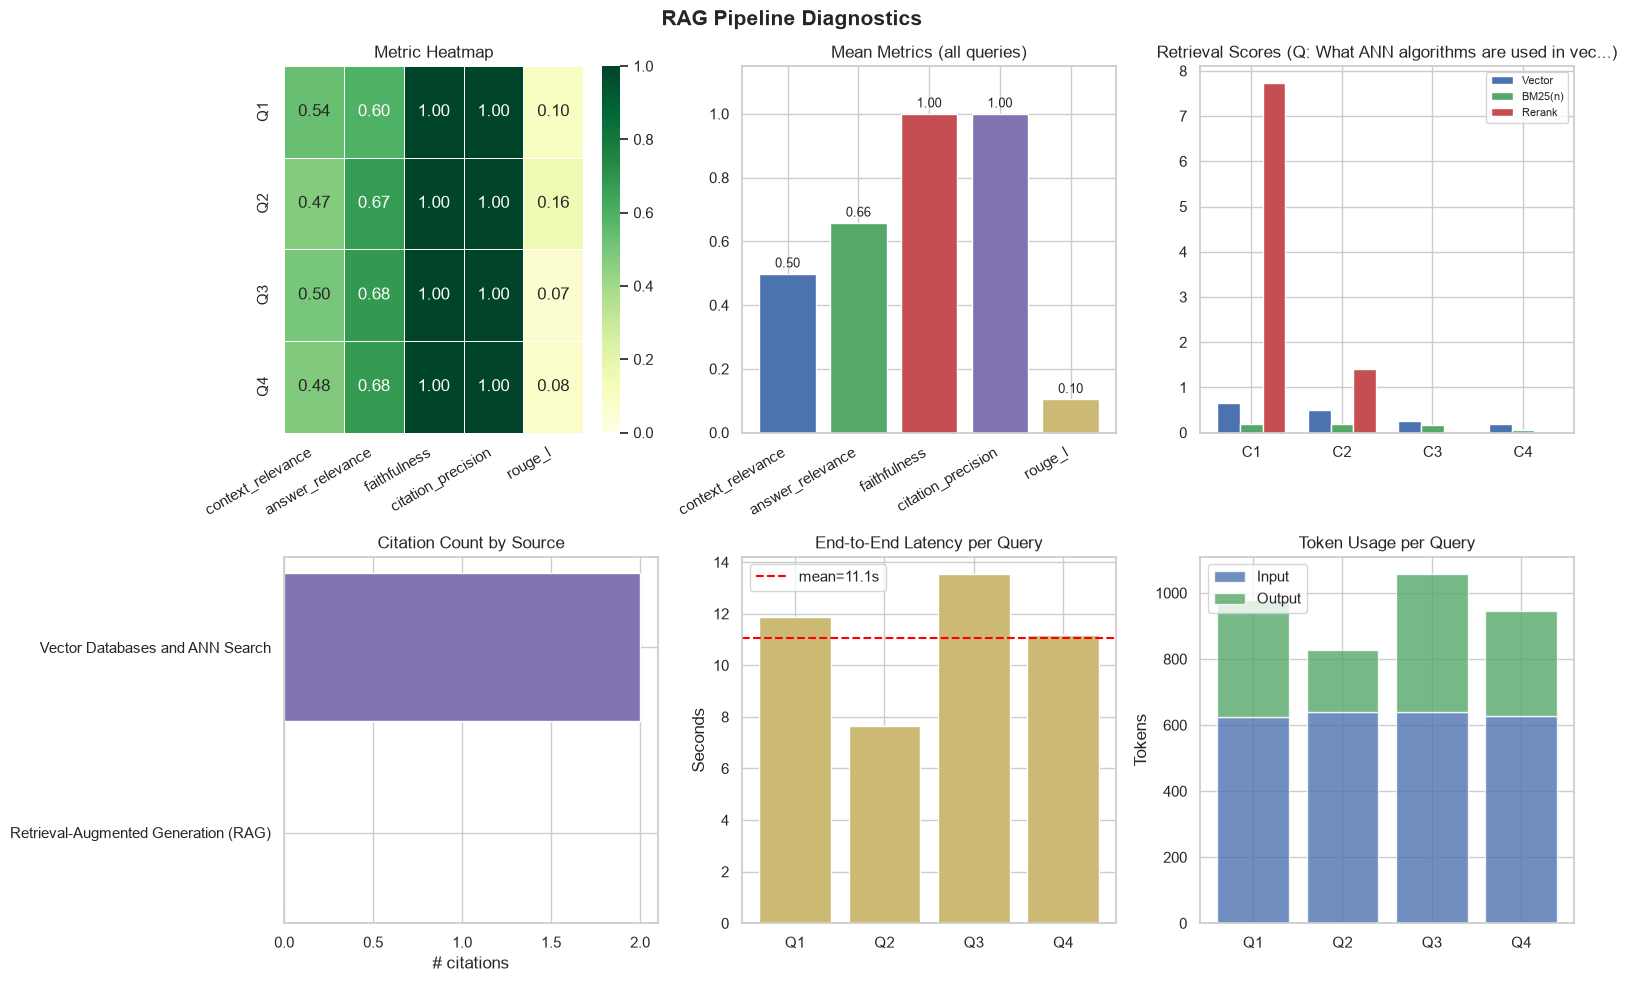

In [13]:
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("RAG Pipeline Diagnostics", fontsize=15, fontweight="bold")

# ── 1. Metric heatmap across queries ─────────────────────────────────────────
ax = axes[0, 0]
metric_cols = ["context_relevance", "answer_relevance",
               "faithfulness", "citation_precision", "rouge_l"]
heat = bench_df[metric_cols].astype(float)
sns.heatmap(heat, ax=ax, annot=True, fmt=".2f", cmap="YlGn",
            vmin=0, vmax=1, linewidths=0.5,
            yticklabels=[f"Q{i+1}" for i in range(len(bench_df))])
ax.set_title("Metric Heatmap")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

# ── 2. Mean metrics bar chart ─────────────────────────────────────────────────
ax = axes[0, 1]
means = heat.mean()
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]
bars  = ax.bar(means.index, means.values, color=colors)
for bar, val in zip(bars, means.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f"{val:.2f}", ha='center', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_title("Mean Metrics (all queries)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

# ── 3. Retrieval score breakdown for last query ───────────────────────────────
ax = axes[0, 2]
last_resp = resp   # from the last benchmark query
labels = [f"C{i+1}" for i in range(len(last_resp.chunks_used))]
vec_s  = [rc.vector_score for rc in last_resp.chunks_used]
bm25_s = [min(rc.bm25_score, 1.0) / max(max(vec_s + [rc.bm25_score for rc in last_resp.chunks_used]), 1)
          for rc in last_resp.chunks_used]  # normalise BM25 for display
rer_s  = [max(rc.rerank_score, 0) for rc in last_resp.chunks_used]
x = np.arange(len(labels))
w = 0.25
ax.bar(x - w, vec_s,  w, label="Vector",  color="#4C72B0")
ax.bar(x,     bm25_s, w, label="BM25(n)", color="#55A868")
ax.bar(x + w, rer_s,  w, label="Rerank",  color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title(f"Retrieval Scores (Q: {last_resp.query[:35]}...)")
ax.legend(fontsize=8)

# ── 4. Citation map ───────────────────────────────────────────────────────────
ax = axes[1, 0]
all_doc_titles = sorted({rc.chunk.doc_title for rc in last_resp.chunks_used})
cite_counts    = {t: 0 for t in all_doc_titles}
for c in last_resp.citations:
    if c.doc_title in cite_counts:
        cite_counts[c.doc_title] += 1
ax.barh(list(cite_counts.keys()), list(cite_counts.values()), color="#8172B2")
ax.set_title("Citation Count by Source")
ax.set_xlabel("# citations")

# ── 5. Latency breakdown ──────────────────────────────────────────────────────
ax = axes[1, 1]
latencies = bench_df["latency_s"].tolist()
ax.bar([f"Q{i+1}" for i in range(len(latencies))], latencies, color="#CCB974")
ax.axhline(np.mean(latencies), ls="--", color="red", label=f"mean={np.mean(latencies):.1f}s")
ax.set_title("End-to-End Latency per Query")
ax.set_ylabel("Seconds")
ax.legend()

# ── 6. Token usage ────────────────────────────────────────────────────────────
ax = axes[1, 2]
in_toks  = bench_df["input_tokens"].tolist()
out_toks = bench_df["output_tokens"].tolist()
qs = [f"Q{i+1}" for i in range(len(in_toks))]
ax.bar(qs, in_toks,  label="Input",  color="#4C72B0", alpha=0.8)
ax.bar(qs, out_toks, label="Output", color="#55A868", alpha=0.8,
       bottom=in_toks)
ax.set_title("Token Usage per Query")
ax.set_ylabel("Tokens")
ax.legend()

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/rag_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Diagnostics chart saved ✓")

In [ ]:
# ── Citation provenance report ─────────────────────────────────────────────────

def print_provenance_report(response: RAGResponse):
    print("\n" + "═"*70)
    print("PROVENANCE REPORT")
    print("═"*70)
    print(f"Query   : {response.query}")
    print(f"Latency : {response.latency_s}s")
    print(f"Tokens  : {response.input_tokens} in / {response.output_tokens} out")
    print()
    print("Retrieved chunks:")
    for i, rc in enumerate(response.chunks_used, 1):
        cited = any(c.citation_id == i for c in response.citations)
        mark  = "✓ cited" if cited else "  unused"
        print(f"  [{i}] {mark:10} | vec={rc.vector_score:.3f} "
              f"bm25={rc.bm25_score:.2f} rerank={rc.rerank_score:.3f}")
        print(f"       {rc.chunk.doc_title} — {rc.chunk.text[:80]}...")
    print()
    print("Citations in answer:")
    for c in response.citations:
        print(f"  [{c.citation_id}] {c.doc_title}")
        print(f"       {c.doc_source}")
        print(f"       '{c.quote[:100]}...'")

print_provenance_report(response)

---
## 10. Advanced Patterns & Design Notes

### Retrieval Strategy Selection

| Query type | Recommended retriever | Rationale |
|------------|----------------------|-----------|
| Semantic / conceptual | Dense (vector) only | Best for paraphrase & concept queries |
| Exact term / acronym | BM25 only | Rare terms not well-embedded |
| Mixed / production | Hybrid (RRF) | Best overall recall |
| Re-ranking critical | Hybrid → CrossEncoder | Highest precision |

### Chunking Selection

| Content type | Strategy | Chunk size |
|--------------|----------|------------|
| Long-form prose | Sentence-aware | 128–256 tokens |
| Technical docs | Parent-child | Parent 512, child 128 |
| FAQ / short entries | Fixed-size | 64–128 tokens |
| Code | File-level + function-level | Natural boundaries |

### Citation Tracking Patterns

1. **Inline tags** (`[N]`) — easiest for users to read, requires prompt engineering.
2. **Structured output** — LLM returns JSON with `{answer, citations: [{text, source}]}`, parsed programmatically.
3. **Post-hoc attribution** — embed every sentence in the answer and match to nearest chunk; works without prompting.
4. **Anthropic Citations API** — use `citations: true` in the request for native citation support.

### Production Checklist

- [ ] Chunk overlap tuned to avoid boundary-crossing facts
- [ ] Embeddings versioned and stored with chunks (re-embed on model upgrade)
- [ ] BM25 index rebuilt on each corpus update
- [ ] RRF `k` hyperparameter tuned on held-out eval set
- [ ] Faithfulness check enabled for high-stakes answers
- [ ] Budget guardrails on retrieval + generation token counts
- [ ] Citation precision tracked in production dashboards
- [ ] Fallback to "I don't know" when max retrieved score < threshold